In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
np.random.seed(42)
X = np.random.rand(100, 1) - 0.5
y = 3 * X[:, 0] ** 2 + 0.05 * np.random.randn(100)

In [ ]:
df = pd.DataFrame()

df["X"] = X.reshape(100)
df["y"] = y

df

,X,y
0,-0.125460,0.051573
1,0.450714,0.594480
2,0.231994,0.166052
3,0.098658,-0.070178
4,-0.343981,0.343986
...,...,...
95,-0.006204,-0.040675
96,0.022733,-0.002305
97,-0.072459,0.032809
98,-0.474581,0.689516


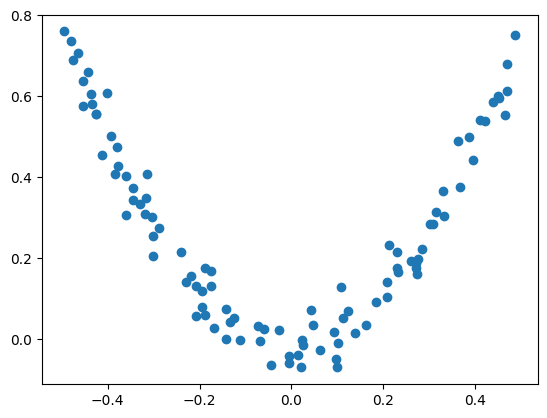

In [ ]:
plt.scatter(X, y)

#### Applying `GradientBoost`

In [ ]:
df["pred1"] = df["y"].mean()
df["res1"] = df["y"] - df["pred1"]

In [ ]:
from sklearn.tree import DecisionTreeRegressor

tree1 = DecisionTreeRegressor(max_leaf_nodes=8)
tree1.fit(df["X"].values.reshape(100, 1), df["res1"].values)

DecisionTreeRegressor(max_leaf_nodes=8)

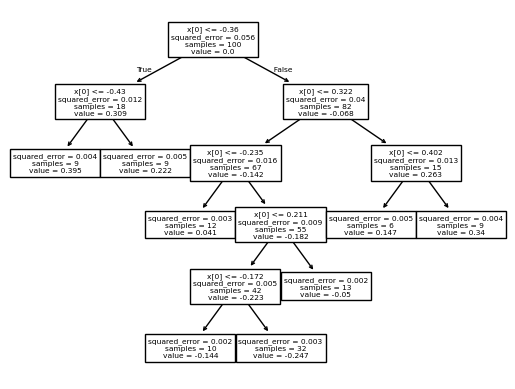

In [9]:
from sklearn.tree import plot_tree

plot_tree(tree1)
plt.show()

#### generating X_test

In [ ]:
X_test = np.linspace(-0.5, 0.5, 500)

y_pred = df["pred1"][0] + tree1.predict(X_test.reshape(500, 1))

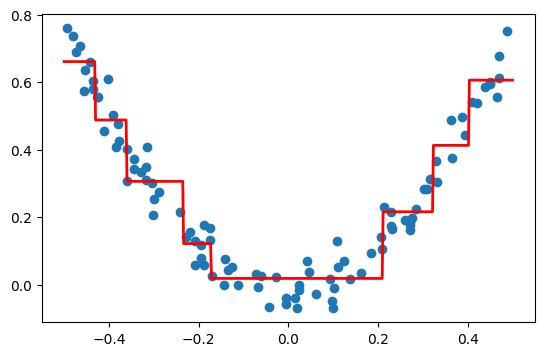

In [12]:
plt.figure(figsize=(14, 4))
plt.subplot(121)
plt.plot(X_test, y_pred, linewidth=2, color="red")
plt.scatter(df["X"], df["y"])

In [ ]:
df["pred2"] = df["pred1"][0] + tree1.predict(df["X"].values.reshape(100, 1))
df["res2"] = df["y"] - df["pred2"]

In [16]:
tree2 = DecisionTreeRegressor(max_leaf_nodes=8)
tree2.fit(df["X"].values.reshape(100, 1), df["res2"].values)


y_pred = df["pred1"][0] + sum(
    reg.predict(X_test.reshape(-1, 1)) for reg in [tree1, tree2]
)


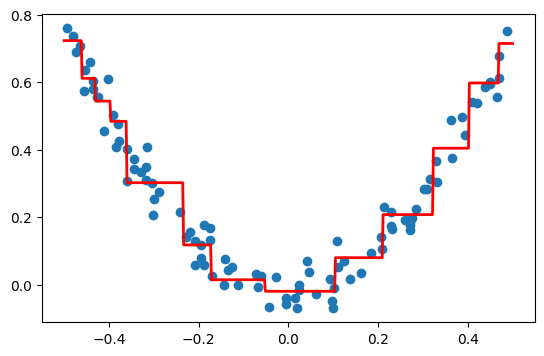

In [17]:
plt.figure(figsize=(14, 4))
plt.subplot(121)
plt.plot(X_test, y_pred, linewidth=2, color="red")
plt.scatter(df["X"], df["y"])